In [1]:
!pip install librosa soundfile torch torchvision torchaudio scikit-learn matplotlib seaborn -q

In [5]:
import os, glob, librosa, numpy as np, pandas as pd

# Mapping the 3rd part of the filename to actual emotion labels
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

def parse_ravdess(base_path):
    data = []
    # Recursively find all .wav files in the Kaggle input directory
    for wav_path in glob.glob(os.path.join(base_path, '**/*.wav'), recursive=True):
        fname = os.path.basename(wav_path)
        parts = fname.split('-')
        
        # Ensure it's a valid RAVDESS file by checking its length
        if len(parts) >= 3:
            emotion_code = parts[2] # Extract the emotion identifier
            if emotion_code in emotion_map:
                data.append({'path': wav_path, 'emotion': emotion_map[emotion_code]})
                
    return pd.DataFrame(data)

# Kaggle automatically mounts the dataset at this specific path
df = parse_ravdess('/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio')

# Let's take a look at the first few rows
df.head()

,path,emotion
0,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,surprised
1,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,neutral
2,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,disgust
3,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,disgust
4,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,neutral


/tmp/ipykernel_57/3410576476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='mako')


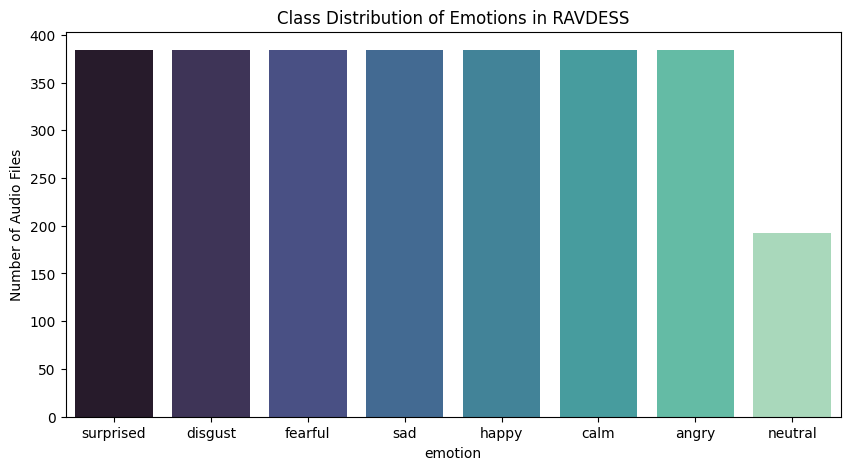

Total valid audio files loaded: 2880


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='mako')
plt.title('Class Distribution of Emotions in RAVDESS')
plt.ylabel('Number of Audio Files')
plt.show()

print(f"Total valid audio files loaded: {len(df)}")

In [7]:
import librosa
import numpy as np

def extract_features(file_path, n_mfcc=40, max_pad_len=174):
    try:
        # Load audio: 22050 Hz sample rate, max 3 seconds long, skipping the first 0.5s of silence
        audio, sr = librosa.load(file_path, sr=22050, duration=3.0, offset=0.5)
        
        # 1. Extract standard MFCCs
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # 2. Extract first derivative (velocity of speech features)
        delta = librosa.feature.delta(mfcc)
        
        # 3. Extract second derivative (acceleration of speech features)
        delta2 = librosa.feature.delta(mfcc, order=2)
        
        # Stack them vertically to create a comprehensive feature map
        combined = np.vstack([mfcc, delta, delta2])
        
        # Ensure uniform shape (pad with zeros if too short, slice if too long)
        if combined.shape[1] < max_pad_len:
            pad_width = max_pad_len - combined.shape[1]
            combined = np.pad(combined, pad_width=((0,0),(0,pad_width)), mode='constant')
        else:
            combined = combined[:, :max_pad_len]
            
        return combined  # Expected shape: (120, 174)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

features, labels = [], []

print("Starting feature extraction... This may take a few minutes.")

# Loop through our dataframe and extract features for every file
for _, row in df.iterrows():
    feat = extract_features(row['path'])
    if feat is not None:
        features.append(feat)
        labels.append(row['emotion'])

# Convert lists to NumPy arrays for machine learning
X = np.array(features)
y = np.array(labels)

print(f"Feature extraction complete! Feature array shape: {X.shape}")

Starting feature extraction... This may take a few minutes.
Feature extraction complete! Feature array shape: (2880, 120, 174)


In [9]:
print(X)

[[[-7.6441125e+02 -7.6441125e+02 -7.6441125e+02 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  ...
  [ 3.4087455e-01  3.4087455e-01  3.4087455e-01 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 2.9367054e-01  2.9367054e-01  2.9367054e-01 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 2.5744119e-01  2.5744119e-01  2.5744119e-01 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]]

 [[-8.2885352e+02 -8.2885352e+02 -8.2768256e+02 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 0.0000000e+00  0.0000000e+00 -1.3322587e+00 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  [ 0.0000000e+00  0.0000000e+00  4.8801011e-01 ...  0.0000000e+00
    0.0000000e+00  0.0000000e+00]
  ...
  [ 2.5567958e-02  2.5567958e-02  2.5567958e-02 ...  0.0000000e+00
    0.0000

In [11]:
print(y)

['surprised' 'neutral' 'disgust' ... 'sad' 'disgust' 'angry']


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import pickle

# 1. Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Reshape for PyTorch CNN
# PyTorch expects the shape: (Batch_Size, Channels, Height, Width)
# Our data is currently (2880, 120, 174). We need to add a "Channel" dimension of 1.
X_reshaped = X[:, np.newaxis, :, :] 

# 3. Split the data (80% Train, 10% Validation, 10% Test)
# Stratify ensures every emotion is equally represented in all splits
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# 4. Convert NumPy arrays to PyTorch Tensors
train_data = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_data = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_data = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

# 5. Create DataLoaders
# DataLoaders feed the data to the GPU in small batches (32 at a time) so memory isn't overwhelmed
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# 6. Save the Label Encoder for our backend API later
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")
print("Data preprocessing complete and Label Encoder saved!")

Training batches: 65
Validation batches: 8
Testing batches: 18
Data preprocessing complete and Label Encoder saved!


In [13]:
import os
from IPython.display import FileLink

# Check if the file is actually there
if os.path.exists('label_encoder.pkl'):
    print("File found! Click the link below to download:")
    display(FileLink('label_encoder.pkl'))
else:
    print("File not found. We might need to re-run the Step 5 cell!")

File found! Click the link below to download:


/kaggle/working/label_encoder.pkl

In [14]:
import torch.nn as nn
import torch.nn.functional as F

class CNNLSTM(nn.Module):
    def __init__(self, num_classes=8):
        super(CNNLSTM, self).__init__()
        # --- CNN Blocks (The Feature Extractors) ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.25)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.25)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout2d(0.3)
        
        # --- The Bridge ---
        # After 3 MaxPool2D layers: Height = 120 / 8 = 15. Width = 174 / 8 = 21.
        # Feature map size: 128 channels * 15 (height) = 1920 features per time step
        
        # --- LSTM Blocks (The Time Trackers) ---
        self.lstm = nn.LSTM(input_size=1920, hidden_size=128, batch_first=True, dropout=0.3)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=64, batch_first=True, dropout=0.3)
        
        # --- Classifier Head (The Decision Makers) ---
        self.fc1 = nn.Linear(64, 64)
        self.drop_fc = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Pass data through CNNs
        x = self.drop1(self.pool1(F.relu(self.bn1(self.conv1(x)))))
        x = self.drop2(self.pool2(F.relu(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(F.relu(self.bn3(self.conv3(x)))))
        
        # Reshape for LSTM: (Batch, Sequence_length, Features)
        b, c, h, w = x.size()
        x = x.view(b, c * h, w)  # Flatten channels and height (B, 1920, 21)
        x = x.permute(0, 2, 1)   # Swap dimensions so time is first: (B, 21, 1920)
        
        # Pass through LSTMs
        x, _ = self.lstm(x)
        x, _ = self.lstm2(x)
        
        # Grab only the final time step's output
        x = x[:, -1, :]  # Shape: (B, 64)
        
        # Pass through final linear layers to get 8 emotion probabilities
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)  
        return x

# Check if Kaggle GPU is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the model and send it to the GPU
model = CNNLSTM().to(device)

print(f"Model successfully built and loaded onto: {device}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Model successfully built and loaded onto: cuda


In [15]:
import torch.optim as optim

# 1. Setup the Training Tools
criterion = nn.CrossEntropyLoss() # Measures how wrong the predictions are
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Updates the weights to fix the errors
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=7, min_lr=1e-6) # Slows down learning if it gets stuck

epochs = 100
best_acc = 0.0
patience_counter = 0
early_stop_patience = 15 # Will stop training if accuracy doesn't improve for 15 rounds

print("Starting the training engine... Grab a coffee, this will take a few minutes!")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device) # Send data to GPU
        
        optimizer.zero_grad() # Clear old math
        outputs = model(inputs) # Make predictions
        loss = criterion(outputs, labels) # Calculate error
        loss.backward() # Calculate adjustments
        optimizer.step() # Apply adjustments
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        
    # --- VALIDATION PHASE (Testing on unseen data) ---
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad(): # Freeze weights, no learning here
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            
    # Calculate final accuracy for this epoch
    val_acc = val_correct.double() / len(val_loader.dataset)
    scheduler.step(val_acc)
    
    print(f'Epoch {epoch+1}: Val Acc: {val_acc:.4f}')
    
    # --- SAVE BEST MODEL & EARLY STOPPING ---
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth') # Save the best version
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Reload the best weights before moving to testing
model.load_state_dict(torch.load('best_model.pth'))
print(f"Training finished! Best Validation Accuracy: {best_acc:.4f}")

Starting the training engine... Grab a coffee, this will take a few minutes!
Epoch 1: Val Acc: 0.1558
Epoch 2: Val Acc: 0.1732
Epoch 3: Val Acc: 0.2468
Epoch 4: Val Acc: 0.2814
Epoch 5: Val Acc: 0.2727
Epoch 6: Val Acc: 0.3074
Epoch 7: Val Acc: 0.3030
Epoch 8: Val Acc: 0.3247
Epoch 9: Val Acc: 0.3810
Epoch 10: Val Acc: 0.4242
Epoch 11: Val Acc: 0.4719
Epoch 12: Val Acc: 0.3680
Epoch 13: Val Acc: 0.4459
Epoch 14: Val Acc: 0.4156
Epoch 15: Val Acc: 0.4113
Epoch 16: Val Acc: 0.5325
Epoch 17: Val Acc: 0.5325
Epoch 18: Val Acc: 0.4892
Epoch 19: Val Acc: 0.4935
Epoch 20: Val Acc: 0.4978
Epoch 21: Val Acc: 0.5108
Epoch 22: Val Acc: 0.5368
Epoch 23: Val Acc: 0.5022
Epoch 24: Val Acc: 0.5541
Epoch 25: Val Acc: 0.5152
Epoch 26: Val Acc: 0.5974
Epoch 27: Val Acc: 0.5584
Epoch 28: Val Acc: 0.6407
Epoch 29: Val Acc: 0.6277
Epoch 30: Val Acc: 0.5801
Epoch 31: Val Acc: 0.5714
Epoch 32: Val Acc: 0.6364
Epoch 33: Val Acc: 0.6277
Epoch 34: Val Acc: 0.6450
Epoch 35: Val Acc: 0.6667
Epoch 36: Val Acc: 0.6

Evaluating on hidden Test Data...

Classification Report:
              precision    recall  f1-score   support

       angry       0.90      0.92      0.91        76
        calm       0.89      0.91      0.90        77
     disgust       0.92      0.91      0.92        77
     fearful       0.87      0.88      0.88        77
       happy       0.83      0.81      0.82        77
     neutral       0.81      0.76      0.78        38
         sad       0.80      0.83      0.82        77
   surprised       0.97      0.94      0.95        77

    accuracy                           0.88       576
   macro avg       0.87      0.87      0.87       576
weighted avg       0.88      0.88      0.88       576



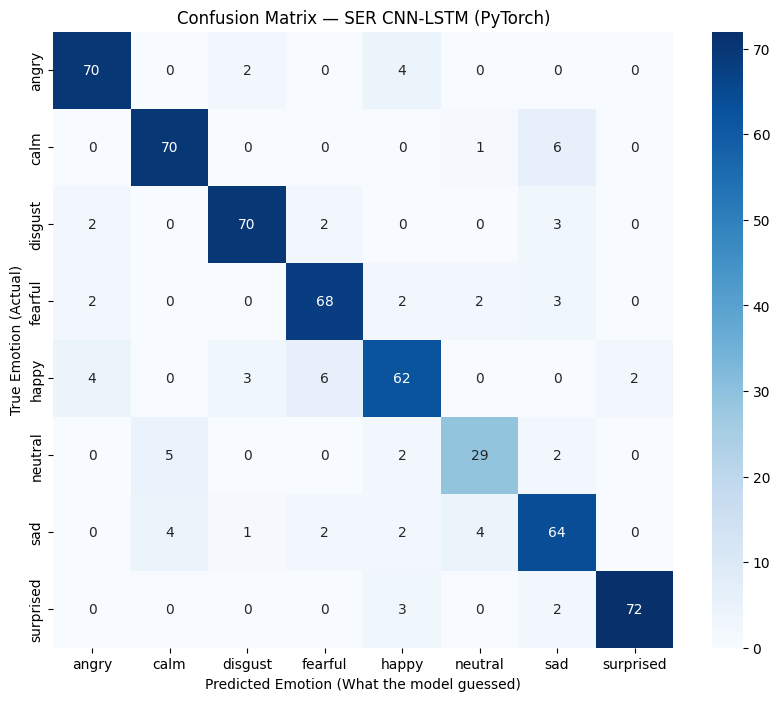

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Put the model in evaluation mode
model.eval()

all_preds, all_labels = [], []

# 2. Run the test data through the model
print("Evaluating on hidden Test Data...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Move predictions back to the CPU so scikit-learn can read them
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Print the text report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# 4. Draw the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix — SER CNN-LSTM (PyTorch)')
plt.ylabel('True Emotion (Actual)')
plt.xlabel('Predicted Emotion (What the model guessed)')

# Save the image for your GitHub README later
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [17]:
# Save the model's learned weights to a .pth file
torch.save(model.state_dict(), 'ser_cnn_lstm.pth')

print("Final PyTorch model saved as 'ser_cnn_lstm.pth'!")
print("Download this file from the Kaggle Output panel, along with your 'label_encoder.pkl' and 'confusion_matrix.png'.")

Final PyTorch model saved as 'ser_cnn_lstm.pth'!
Download this file from the Kaggle Output panel, along with your 'label_encoder.pkl' and 'confusion_matrix.png'.


In [18]:
import os
from IPython.display import FileLink, display

files_to_download = ['ser_cnn_lstm.pth', 'label_encoder.pkl', 'confusion_matrix.png']

print("Checking for files...")
for file in files_to_download:
    if os.path.exists(file):
        print(f"✅ Found {file}! Click below to download:")
        display(FileLink(file))
        print("-" * 30)
    else:
        print(f"❌ {file} not found. You might need to re-run the cell that created it.")

Checking for files...
✅ Found ser_cnn_lstm.pth! Click below to download:


/kaggle/working/ser_cnn_lstm.pth

------------------------------
✅ Found label_encoder.pkl! Click below to download:


/kaggle/working/label_encoder.pkl

------------------------------
✅ Found confusion_matrix.png! Click below to download:


/kaggle/working/confusion_matrix.png

------------------------------
